# ADMISSION DATA EXPLORER
## FIP GAIDS 2026 Final Project


In [1]:
#Import modules
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Set File Path

PATH = Path(_dh[0]).resolve()
print(PATH)
FilePath = PATH / "admission_trends_sample.csv"
print(FilePath)

C:\Users\User\Desktop\Mr Ope\GrandMEAN_Portfolio\FlexiSaf\final_projects\admission_dashboard
C:\Users\User\Desktop\Mr Ope\GrandMEAN_Portfolio\FlexiSaf\final_projects\admission_dashboard\admission_trends_sample.csv


In [45]:
#Read in the dataset
data_ = pd.read_csv(FilePath)
data_.head()

,trend_id,school_id,academic_year,num_applications,num_accepted,num_enrolled,acceptance_rate,enrollment_rate,country
0,NGA_SCH_008889_ADM_2017,NGA_SCH_008889,2017/2018,1484.0,1367.0,1269.0,0.921583,0.928464,Nigeria
1,NGA_SCH_009417_ADM_2020,NGA_SCH_009417,2020/2021,1873.0,954.0,888.0,NaN,0.930981,Nigeria
2,NGA_SCH_002318_ADM_2019,NGA_SCH_002318,2019/2020,1514.0,1145.0,1060.0,0.756489,0.926466,Nigeria
3,NGA_SCH_009003_ADM_2018,NGA_SCH_009003,2018/2019,378.0,230.0,178.0,0.610822,0.776951,Nigeria
4,NGA_SCH_010931_ADM_2024,NGA_SCH_010931,2024/2025,1117.0,804.0,738.0,0.720597,0.918145,Nigeria


### Clean Dataset

In [46]:
#Explore the dataset
print(data_.info(),'\n\n',data_.describe(), '\n\n',data_.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   trend_id          10000 non-null  object 
 1   school_id         10000 non-null  object 
 2   academic_year     10000 non-null  object 
 3   num_applications  9788 non-null   float64
 4   num_accepted      9823 non-null   float64
 5   num_enrolled      9817 non-null   float64
 6   acceptance_rate   9798 non-null   float64
 7   enrollment_rate   9786 non-null   float64
 8   country           9898 non-null   object 
dtypes: float64(5), object(4)
memory usage: 703.3+ KB
None 

        num_applications  num_accepted  num_enrolled  acceptance_rate  \
count       9788.000000   9823.000000   9817.000000      9798.000000   
mean        1029.492644    691.902983    571.209331         0.674655   
std          562.028106    420.707586    351.816499         0.158845   
min           50.000000   

In [47]:
#Check for unique values in the object_typed columns
print(data_['trend_id'].unique(), ' length: ', len(data_['trend_id'].unique()),'\n\n')
print(data_['school_id'].unique(), ' length: ', len(data_['school_id'].unique()),'\n\n')
print(data_['academic_year'].unique(), ' length: ', len(data_['academic_year'].unique()),'\n\n')
print(data_['country'].unique(), ' length: ', len(data_['country'].unique()),'\n\n')

['NGA_SCH_008889_ADM_2017' 'NGA_SCH_009417_ADM_2020'
 'NGA_SCH_002318_ADM_2019' ... 'NGA_SCH_010955_ADM_2023'
 'NGA_SCH_008595_ADM_2024' 'NGA_SCH_008745_ADM_2019']  length:  10000 


['NGA_SCH_008889' 'NGA_SCH_009417' 'NGA_SCH_002318' ... 'NGA_SCH_000580'
 'NGA_SCH_003522' 'NGA_SCH_008595']  length:  6892 


['2017/2018' '2020/2021' '2019/2020' '2018/2019' '2024/2025' '2022/2023'
 '2016/2017' '2023/2024' '2021/2022' '2015/2016' '2014/2015']  length:  11 


['Nigeria' nan]  length:  2 




#### Note 1:
- Country column does not offer any useful information. It should be dropped from the analysis
- Trend_id column offers the same piece of information as the school_id except for additional information on admission year which can also be obtained from 'academic_year' column. We will extract 'calendar_year' from 'trend_id' and drop both 'trend_id' and academic year from the analysis

In [48]:
#Check for missing values
print('Missing values:','\n',data_.isna().sum(),'\n\n')

#Calculate missing value percentage
missing_percentage = data_.isna().sum() / len(data_) * 100
print('Missing value percentage:','\n',missing_percentage,'\n\n')

print(data_[data_.isna().any(axis=1)])

Missing values: 
 trend_id              0
school_id             0
academic_year         0
num_applications    212
num_accepted        177
num_enrolled        183
acceptance_rate     202
enrollment_rate     214
country             102
dtype: int64 


Missing value percentage: 
 trend_id            0.00
school_id           0.00
academic_year       0.00
num_applications    2.12
num_accepted        1.77
num_enrolled        1.83
acceptance_rate     2.02
enrollment_rate     2.14
country             1.02
dtype: float64 


                     trend_id       school_id academic_year  num_applications  \
1     NGA_SCH_009417_ADM_2020  NGA_SCH_009417     2020/2021            1873.0   
15    NGA_SCH_010419_ADM_2019  NGA_SCH_010419     2019/2020            1869.0   
39    NGA_SCH_001878_ADM_2021  NGA_SCH_001878     2021/2022               NaN   
42    NGA_SCH_004701_ADM_2021  NGA_SCH_004701     2021/2022             784.0   
46    NGA_SCH_006058_ADM_2019  NGA_SCH_006058     2019/2020             92

#### Note 2:
- Percentage of missing values in each column is less than 5%. In line with the golden rule, we can safely delete them.
- However, together, there are 1050 rows in total which accounts for over 10% of (10000) records in the dataset

In [49]:
#Fill in missing values in 'num_applications', 'num_accepted' and 'num_enrolled' with the mean of each column

data_['num_applications'].fillna(data_['num_applications'].mean(), inplace=True)
data_['num_accepted'].fillna(data_['num_accepted'].mean(), inplace=True)
data_['num_enrolled'].fillna(data_['num_enrolled'].mean(), inplace=True)

#Recalculate 'acceptance_rate' and 'enrollment_rate' columns
data_['acceptance_rate'] = round(data_['num_accepted'] / data_['num_applications'] * 100,1)
data_['enrollment_rate'] = round(data_['num_enrolled'] / data_['num_accepted'] * 100,1)

print(data_.isna().sum(),'\n\n')
print(data_.describe())


trend_id              0
school_id             0
academic_year         0
num_applications      0
num_accepted          0
num_enrolled          0
acceptance_rate       0
enrollment_rate       0
country             102
dtype: int64 


       num_applications  num_accepted  num_enrolled  acceptance_rate  \
count      10000.000000  10000.000000  10000.000000     10000.000000   
mean        1029.492644    691.902983    571.209331        68.326340   
std          556.038092    416.967325    348.582190        29.177897   
min           50.000000     21.000000     16.000000         3.600000   
25%          564.000000    351.000000    287.000000        53.400000   
50%         1029.492644    664.000000    546.000000        67.100000   
75%         1503.250000    976.250000    806.000000        81.200000   
max         1999.000000   1877.000000   1728.000000      1116.000000   

       enrollment_rate  
count     10000.000000  
mean         84.119930  
std          35.162575  
min           4.500

In [50]:
#Extract calendar year from the 'trend_id' column
data_['cal_year'] = data_['trend_id'].str[-4:].astype(int)

#Convert cal_year to datetime format
data_['cal_year'] = pd.to_datetime(data_['cal_year'], format='%Y').dt.year

#drop trend_id, country and academic_year columns
data_ = data_.drop(columns=['trend_id', 'country', 'academic_year'])

#Sort the data by cal_year in ascending order
data_.sort_values(by='cal_year',ascending=True, inplace=True)
data_.head()


,school_id,num_applications,num_accepted,num_enrolled,acceptance_rate,enrollment_rate,cal_year
409,NGA_SCH_000010,87.0,81.0,66.0,93.1,81.5,2014
7878,NGA_SCH_008696,1691.0,1158.0,958.0,68.5,82.7,2014
9282,NGA_SCH_005835,1675.0,749.0,708.0,44.7,94.5,2014
4128,NGA_SCH_005162,747.0,584.0,509.0,78.2,87.2,2014
4178,NGA_SCH_005115,861.0,482.0,377.0,56.0,78.2,2014


### Exploratory Data Analysis

In [51]:
#Calculate the total number of schools, average yearly applications and application to school ratio

total_num_of_schools = len(data_['school_id'].unique())
print(total_num_of_schools)

avg_yearly_applications = round(data_['num_applications'].sum()/len(data_['cal_year'].unique()),0)
print(avg_yearly_applications)

app_to_sch_ratio = round(avg_yearly_applications/total_num_of_schools,0)
print(app_to_sch_ratio)

6892
935902.0
136.0


           School_Id  Admission Records Count
0     NGA_SCH_008503                        5
1     NGA_SCH_010175                        5
2     NGA_SCH_002939                        5
3     NGA_SCH_009943                        5
4     NGA_SCH_001521                        5
...              ...                      ...
6887  NGA_SCH_010965                        1
6888  NGA_SCH_006166                        1
6889  NGA_SCH_011020                        1
6890  NGA_SCH_003063                        1
6891  NGA_SCH_002580                        1

[6892 rows x 2 columns]


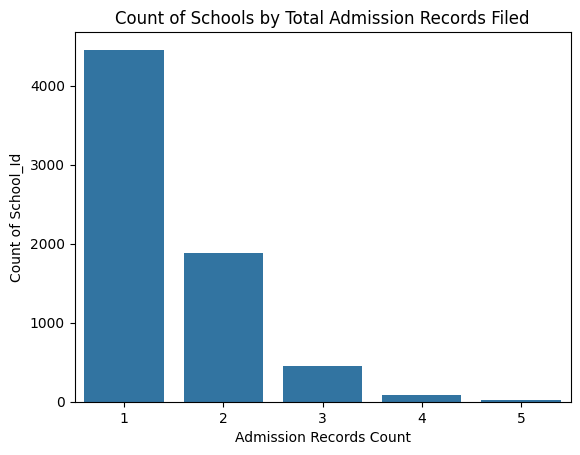

In [52]:
#Calculate the total number of admission records filed for each school

records = data_['school_id'].value_counts().reset_index()
records.columns=['School_Id','Admission Records Count']
print(records)

sns.countplot(data=records, x='Admission Records Count')
plt.xlabel('Admission Records Count')
plt.ylabel('Count of School_Id')
plt.title('Count of Schools by Total Admission Records Filed')
plt.show()

    Calendar Year  Admission Records Count
0            2014                      203
1            2015                      380
2            2016                      636
3            2017                      801
4            2018                      962
5            2019                     1198
6            2020                     1178
7            2021                     1132
8            2022                     1209
9            2023                     1105
10           2024                     1196


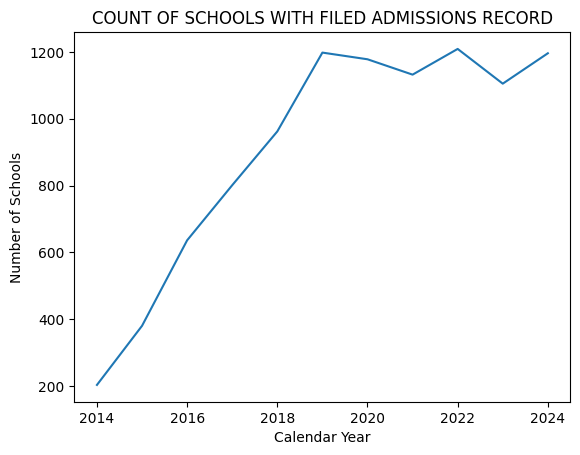

In [54]:
#Calculate the total number of admission records filed for each calendar year
records2 = data_.groupby('cal_year')['school_id'].count().reset_index()
records2.columns=['Calendar Year','Admission Records Count']
print(records2)

sns.lineplot(data=records2, x='Calendar Year', y='Admission Records Count')
plt.xlabel('Calendar Year')
plt.ylabel('Number of Schools')
plt.title('COUNT OF SCHOOLS WITH FILED ADMISSIONS RECORD')
plt.show()

In [56]:
#Identify the number of schools that have filed admission records consistently for the last 5 years

max_year = data_['cal_year'].max()
five_years_bmax = max_year - 5
print(max_year, ' ', five_years_bmax)

data_last5years = data_[data_['cal_year'] >= five_years_bmax]
print(data_last5years.head())

schools = list(data_last5years['school_id'].unique())
print(len(schools))

for year in data_last5years['cal_year'].unique():
    for id in schools:
        if id not in data_last5years[data_last5years['cal_year'] == year]['school_id']:
            schools.remove(id)

print(schools, f'\nOnly {len(schools)} schools have filed admission records consistently for the last 5 years')

2024   2019
           school_id  num_applications  num_accepted  num_enrolled  \
1358  NGA_SCH_009686             679.0    691.902983         262.0   
5805  NGA_SCH_004892             393.0    300.000000         284.0   
5775  NGA_SCH_005879            1942.0   1312.000000         961.0   
4143  NGA_SCH_007434            1859.0   1119.000000         891.0   
5670  NGA_SCH_007562             278.0    113.000000          94.0   

      acceptance_rate  enrollment_rate  cal_year  
1358            101.9             37.9      2019  
5805             76.3             94.7      2019  
5775             67.6             73.2      2019  
4143             60.2             79.6      2019  
5670             40.6             83.2      2019  
5503
['NGA_SCH_006290', 'NGA_SCH_009989', 'NGA_SCH_008062', 'NGA_SCH_002938', 'NGA_SCH_009292', 'NGA_SCH_005005', 'NGA_SCH_004596', 'NGA_SCH_004431', 'NGA_SCH_003052', 'NGA_SCH_001678', 'NGA_SCH_006356', 'NGA_SCH_000555', 'NGA_SCH_006965', 'NGA_SCH_008648', 'NG

In [ ]:
#Aggregate the data by school_id and calculate the average of num_applications, num_accepted and num_enrolled
yearly_average = data_.groupby(['school_id']).agg({
    'num_applications': 'mean',
    'num_accepted': 'mean',
    'num_enrolled': 'mean'
}).reset_index()

yearly_average.columns = ['school_id', 'avg_num_applications', 'avg_num_accepted', 'avg_num_enrolled']
print(yearly_average.head())

#calculate the standard deviation of the average number of applications across schools
stdev_app = yearly_average['avg_num_applications'].std()
print(stdev_app)

        school_id  avg_num_applications  avg_num_accepted  avg_num_enrolled
0  NGA_SCH_000002                 387.0             269.0             227.0
1  NGA_SCH_000005                1186.0             516.0             393.0
2  NGA_SCH_000007                 200.0             139.0             121.0
3  NGA_SCH_000010                 558.5             300.5             232.0
4  NGA_SCH_000011                1597.5             835.0             727.0
500.44885614741463


#### segmentation analysis of schools
- The performance metrics used is the yearly average applications to schools ratio (app_to_sch_ratio)
- Schools with average number of application equal or less than app_to_sch_ratio are classed as UNDER-UTILIZED
- Schools with average number of application within one standard deviation from the app_to_sch_ratio are classed as GOOD-STANDING
- Schools with average number of application equal or greater than one standard deviation from the app_to_sch_ratio are classed as IN-DEMAND

In [58]:
#Perform a segmentation analysis of schools based on the average number of applications received

under_utilized = yearly_average[yearly_average['avg_num_applications'] <= app_to_sch_ratio]
n_under_utilized = len(under_utilized)

top_perf = app_to_sch_ratio + stdev_app
in_demand = yearly_average[yearly_average['avg_num_applications'] >= top_perf]
n_in_demand = len(in_demand)
print(n_in_demand)

good_standing = yearly_average[(yearly_average['avg_num_applications'] > app_to_sch_ratio) & (yearly_average['avg_num_applications'] < top_perf)]
n_good_stand = len(good_standing)
print(n_good_stand)

labels = ['Under-Utilized','Good-standing','In-Demand']
values = [n_under_utilized, n_good_stand, n_in_demand]

perf_frame = list(zip(labels,values))
perf_frame = pd.DataFrame(perf_frame, columns=['Segment','Count'])
print(perf_frame)

5179
1528
          Segment  Count
0  Under-Utilized    185
1   Good-standing   1528
2       In-Demand   5179


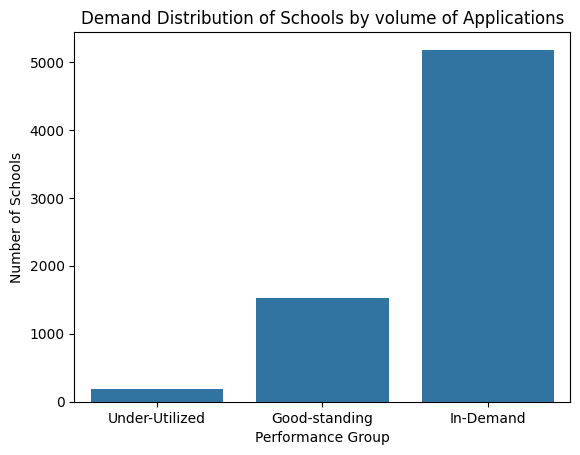

In [60]:
#Plot the demand distribution of schools by volume of applications received
sns.barplot(data=perf_frame, x='Segment', y='Count')
plt.xlabel('Performance Group')
plt.ylabel('Number of Schools')
plt.title('Demand Distribution of Schools by volume of Applications')
plt.show()

### Top-N, Bottom-N Analysis

In [64]:
#Rank schools based on the average number of applications received, average acceptance and average enrollment

rank_col = 'avg_num_applications' #Default ranking column
n = 10 #Default number of schools to rank

rank_size = input("Enter the number of schools to rank (N)")
rank_params = input("Rank by: average yearly applications - press 1; average acceptance - press 2; average enrollment - press 3")

if rank_params:
    if int(rank_params) == 1:
        rank_col = 'avg_num_applications'
    elif int(rank_params) == 2:
        rank_col = 'avg_num_accepted'
    elif int(rank_params) == 3:
        rank_col = 'avg_num_enrolled'
    else:
        print("Invalid input for ranking parameter. Defaulting to average yearly applications.")
else:
    print("No input for ranking parameter. Defaulting to average yearly applications.")

if rank_size:
    n = int(rank_size)
else:    
    print("No input for number of schools to rank. Defaulting to 10.")

top_schools = yearly_average.sort_values(by=rank_col, ascending=False).head(n)
print(f'Top {n} schools ranked by {rank_col.replace("_", " ").title()}:\n',top_schools,']n\n')

bottom_schools = yearly_average.sort_values(by=rank_col, ascending=True).head(n)
print(f'Bottom {n} schools ranked by {rank_col.replace("_", " ").title()}:\n',bottom_schools)

Top 5 schools ranked by Avg Num Accepted:
            school_id  avg_num_applications  avg_num_accepted  avg_num_enrolled
6822  NGA_SCH_011630                1989.0            1872.0            1592.0
4396  NGA_SCH_007438                1970.0            1870.0            1494.0
24    NGA_SCH_000046                1964.0            1863.0            1467.0
5128  NGA_SCH_008705                1949.0            1845.0            1476.0
3851  NGA_SCH_006508                1951.0            1830.0            1642.0 ]n

Bottom 5 schools ranked by Avg Num Accepted:
            school_id  avg_num_applications  avg_num_accepted  avg_num_enrolled
5082  NGA_SCH_008635                  51.0              21.0              16.0
2091  NGA_SCH_003524                  60.0              25.0              23.0
3022  NGA_SCH_005072                  50.0              26.0              21.0
5935  NGA_SCH_010094                  59.0              26.0              22.0
1430  NGA_SCH_002408                  

C:\Users\User\AppData\Local\Temp\ipykernel_10148\1328282548.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(top_ranked_list, rotation=45, ha='right')
C:\Users\User\AppData\Local\Temp\ipykernel_10148\1328282548.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(bottom_ranked_list, rotation=45, ha='right')


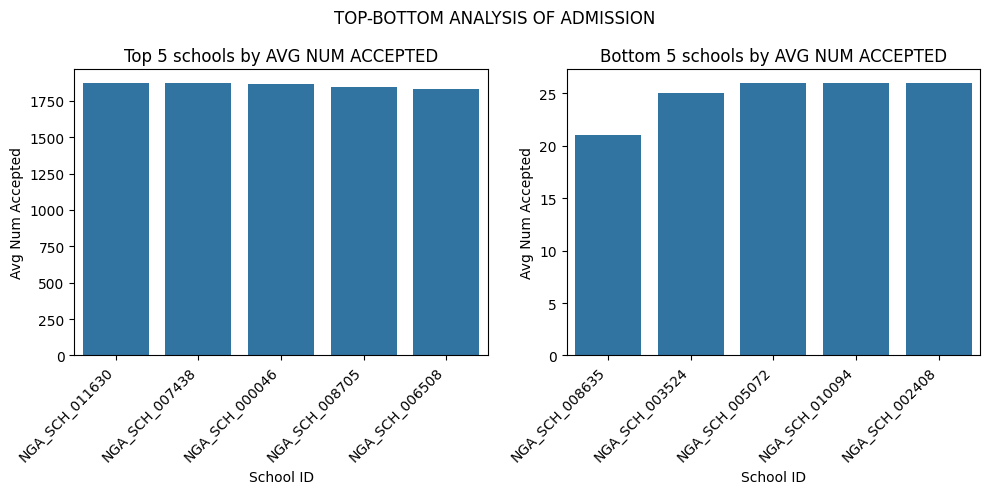

In [66]:
#Create a subset of the original data for the top and bottom ranked schools
top_ranked_list = list(top_schools['school_id'])
top_subset = data_[data_['school_id'].isin(top_ranked_list)]

bottom_ranked_list = list(bottom_schools['school_id'])
bottom_subset = data_[data_['school_id'].isin(bottom_ranked_list)]

#Visualize the top and bottom ranked schools based on the selected ranking parameter
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.barplot(data=top_schools, ax=axes[0], x='school_id', y=rank_col)
axes[0].set_xticklabels(top_ranked_list, rotation=45, ha='right')
sns.barplot(data=bottom_schools, ax=axes[1], x='school_id', y=rank_col)
axes[1].set_xticklabels(bottom_ranked_list, rotation=45, ha='right')
axes[0].set_title(f'Top {n} schools by {rank_col.replace('_', ' ').upper()}')
axes[1].set_title(f'Bottom {n} schools by {rank_col.replace('_', ' ').upper()}')
axes[0].set_xlabel('School ID')
axes[0].set_ylabel(rank_col.replace('_', ' ').title())
axes[1].set_xlabel('School ID')
axes[1].set_ylabel(rank_col.replace('_', ' ').title())
plt.suptitle('TOP-BOTTOM ANALYSIS OF ADMISSION')
plt.tight_layout()
plt.show()

In [67]:
#Aggregate the data by cal_year and calculate the sum of num_applications and num_accepted and num_enrolled for each year

yearly_aggregate = data_.groupby(['cal_year']).agg({
    'num_applications': 'sum',
    'num_accepted': 'sum',
    'num_enrolled': 'sum'
}).reset_index()
print(yearly_aggregate.head())

   cal_year  num_applications   num_accepted   num_enrolled
0      2014      2.163640e+05  141256.611931  116685.837323
1      2015      3.956884e+05  266553.514914  220341.837323
2      2016      6.513864e+05  441813.835794  366134.721300
3      2017      8.159738e+05  549475.223862  452734.349292
4      2018      1.026485e+06  690082.962639  569631.814607


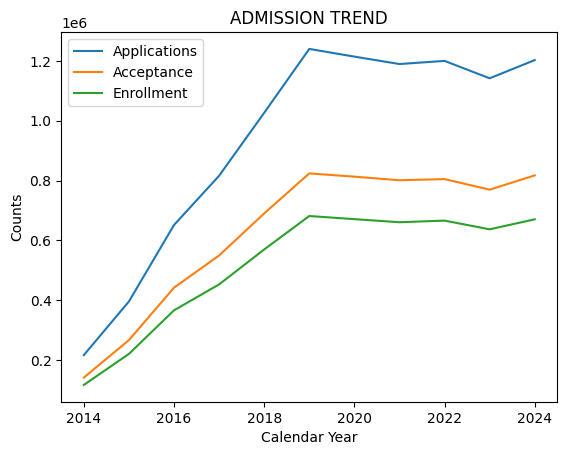

In [68]:
#Visualize the trend of applications, acceptance and enrollment over the years

sns.lineplot(data=yearly_aggregate, x='cal_year', y='num_applications',label='Applications')
sns.lineplot(data=yearly_aggregate, x='cal_year', y='num_accepted', label='Acceptance')
sns.lineplot(data=yearly_aggregate, x='cal_year', y='num_enrolled',label='Enrollment')
plt.legend()
plt.xlabel('Calendar Year')
plt.ylabel('Counts')
plt.title('ADMISSION TREND')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_10148\4257807125.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,0].set_xticklabels(top_ranked_list, rotation=45, ha='right')
C:\Users\User\AppData\Local\Temp\ipykernel_10148\4257807125.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(bottom_ranked_list, rotation=45, ha='right')


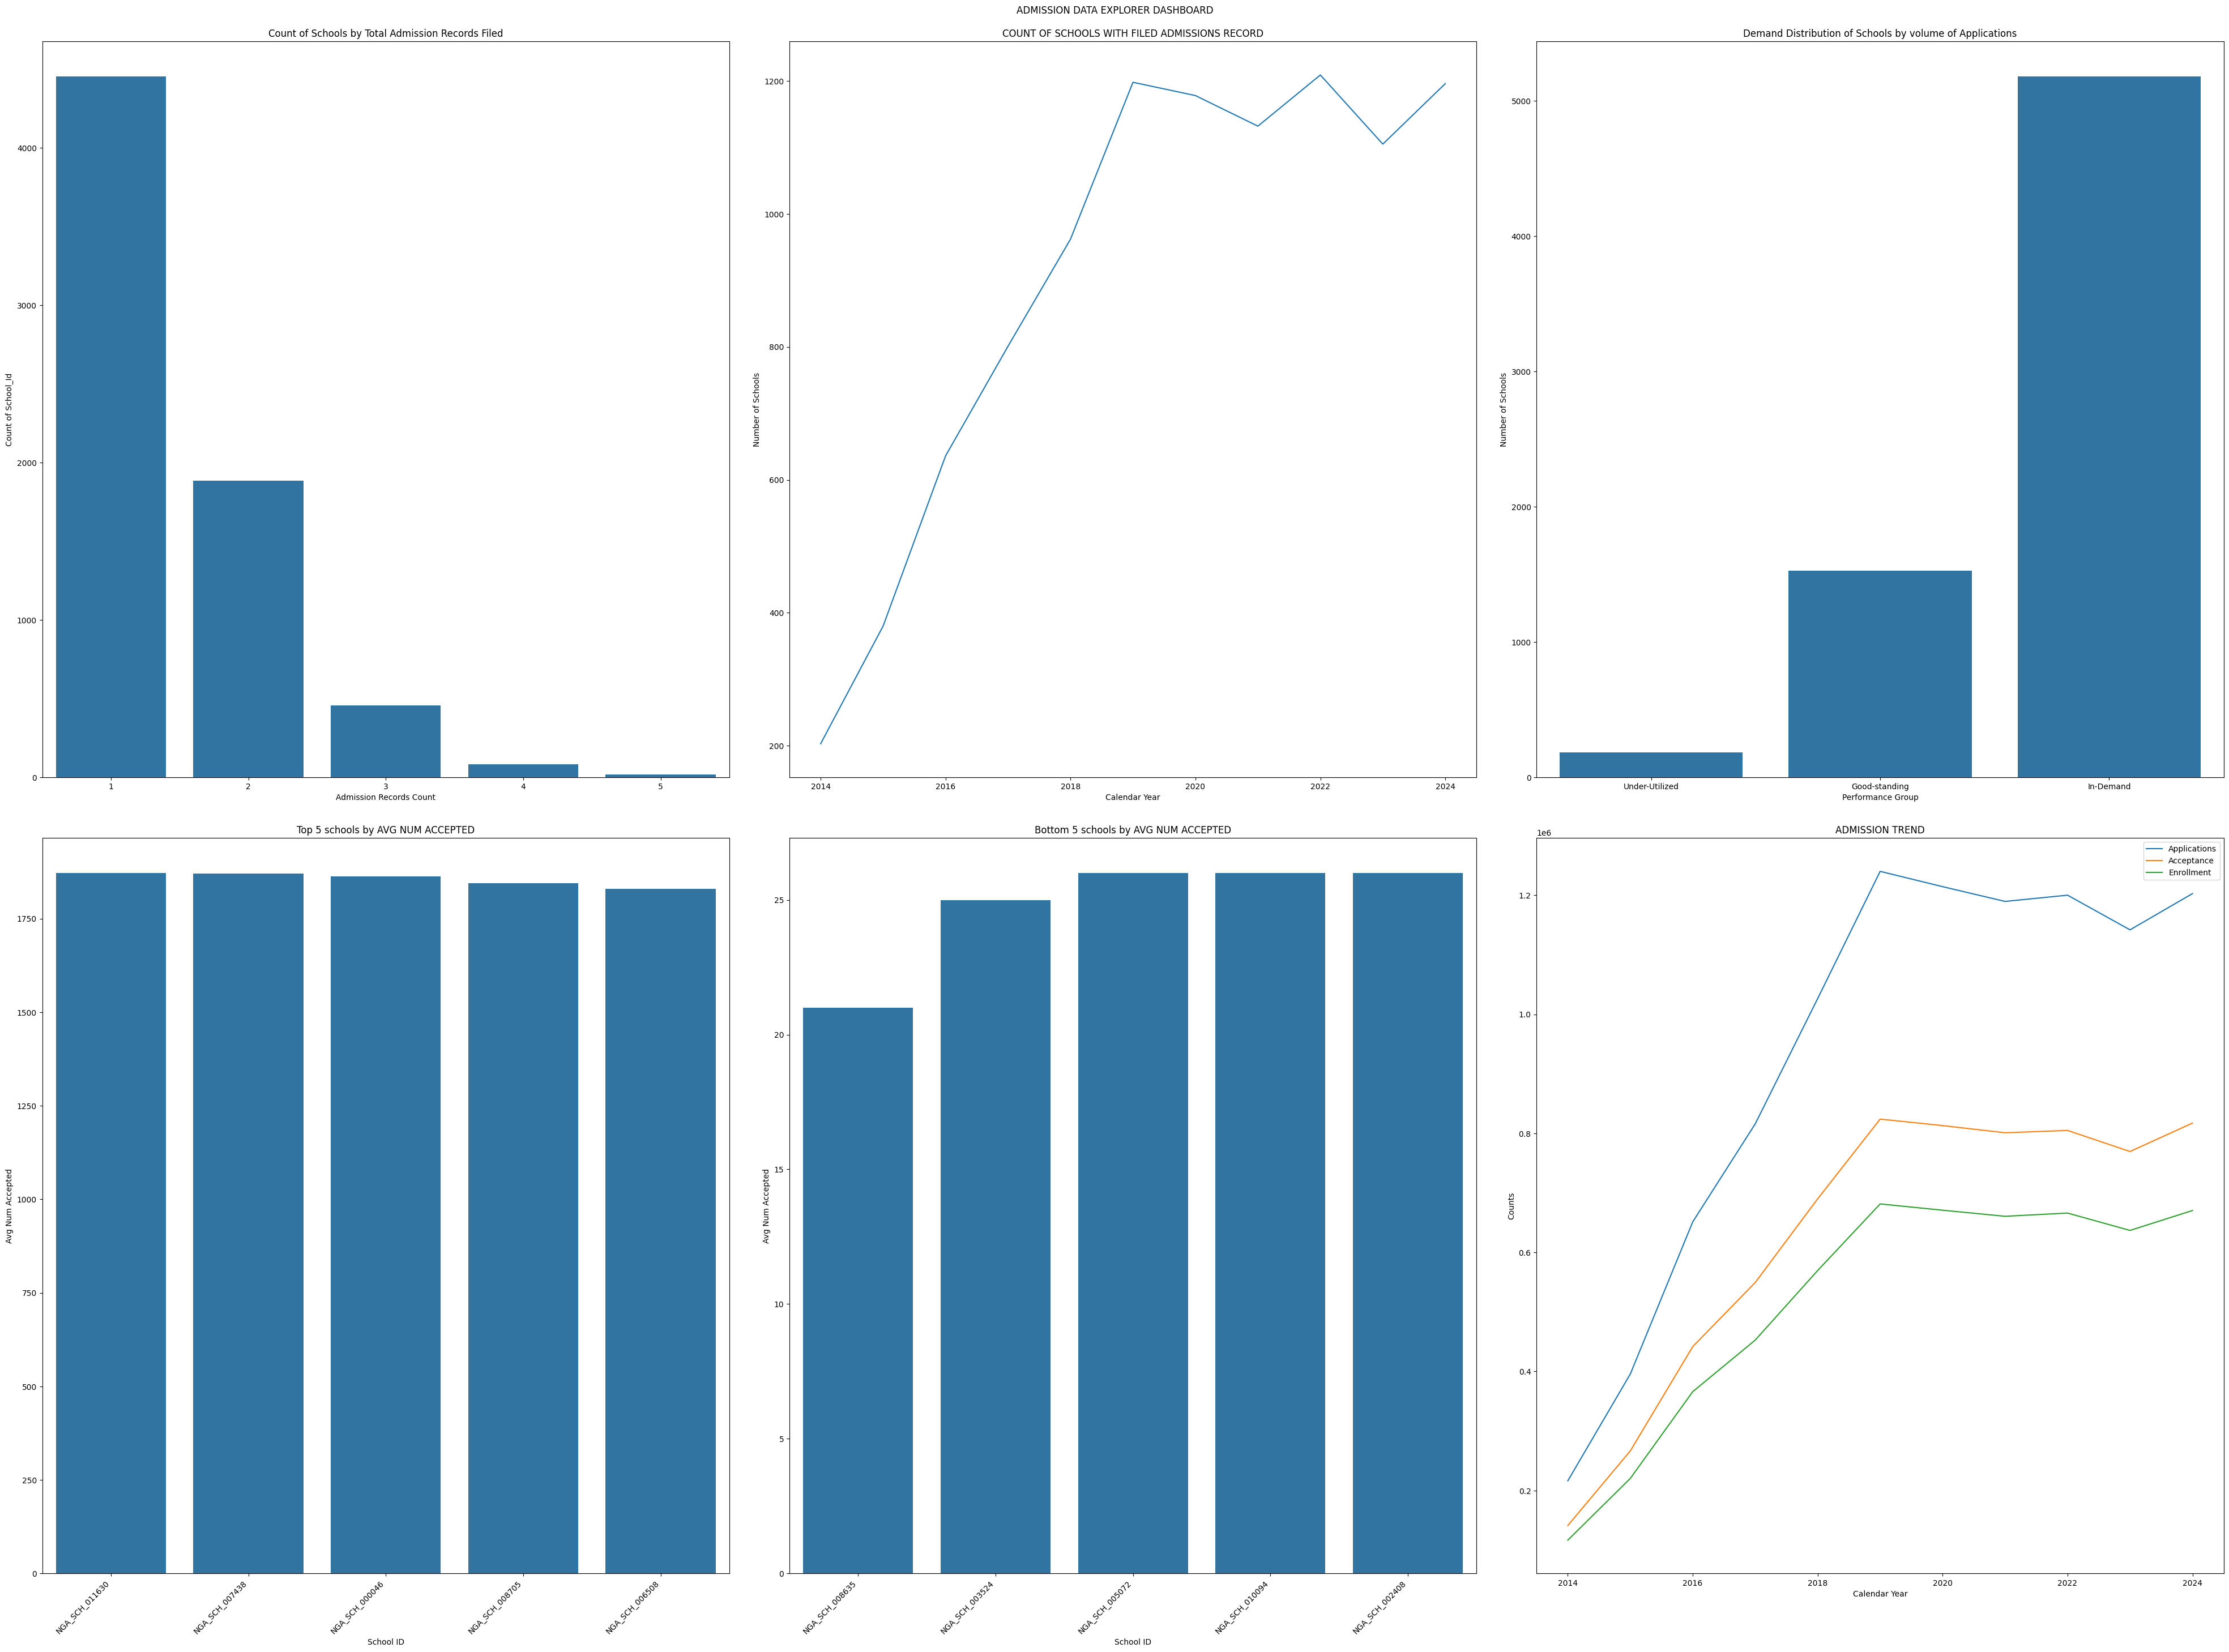

In [ ]:
#Create a dashboard to visualize the key insights from the analysis

fig, axes = plt.subplots(2, 3, figsize=(40,30))
sns.countplot(data=records, x='Admission Records Count', ax=axes[0,0])
axes[0,0].set_xlabel('Admission Records Count')
axes[0,0].set_ylabel('Count of School_Id')
axes[0,0].set_title('Count of Schools by Total Admission Records Filed')

sns.lineplot(data=records2, x='Calendar Year', y='Admission Records Count', ax=axes[0,1])
axes[0,1].set_xlabel('Calendar Year')
axes[0,1].set_ylabel('Number of Schools')
axes[0,1].set_title('COUNT OF SCHOOLS WITH FILED ADMISSIONS RECORD')

sns.barplot(data=perf_frame, x='Segment', y='Count', ax=axes[0,2])
axes[0,2].set_xlabel('Performance Group')
axes[0,2].set_ylabel('Number of Schools')
axes[0,2].set_title('Demand Distribution of Schools by volume of Applications')

sns.barplot(data=top_schools, ax=axes[1,0], x='school_id', y=rank_col)
axes[1,0].set_xticklabels(top_ranked_list, rotation=45, ha='right')
axes[1,0].set_title(f'Top {n} schools by {rank_col.replace('_', ' ').upper()}')
axes[1,0].set_xlabel('School ID')
axes[1,0].set_ylabel(rank_col.replace('_', ' ').title())

sns.barplot(data=bottom_schools, ax=axes[1,1], x='school_id', y=rank_col)
axes[1,1].set_xticklabels(bottom_ranked_list, rotation=45, ha='right')
axes[1,1].set_title(f'Bottom {n} schools by {rank_col.replace('_', ' ').upper()}')
axes[1,1].set_xlabel('School ID')
axes[1,1].set_ylabel(rank_col.replace('_', ' ').title())
plt.suptitle('TOP-BOTTOM ANALYSIS OF ADMISSION')
plt.tight_layout()

sns.lineplot(data=yearly_aggregate, x='cal_year', y='num_applications',label='Applications', ax=axes[1,2])
sns.lineplot(data=yearly_aggregate, x='cal_year', y='num_accepted', label='Acceptance', ax=axes[1,2])
sns.lineplot(data=yearly_aggregate, x='cal_year', y='num_enrolled',label='Enrollment', ax=axes[1,2])
axes[1,2].legend()
axes[1,2].set_xlabel('Calendar Year')
axes[1,2].set_ylabel('Counts')
axes[1,2].set_title('ADMISSION TREND')

plt.suptitle('ADMISSION DATA EXPLORER DASHBOARD')
plt.tight_layout(pad=3)
plt.show()